## **SAVE A COPY OF THIS NOTEBOOK TO PUT ANSWERS INTO. SUBMIT A PDF THAT HAS THE WRITTEN ANSWERS WITH THIS COLAB**

(25 pts)

For our first homework assignment, we want you to perform the process of pre-preocessing data to use for training models. This is especially important in a multimodal setting, where you have several modalities that can be extracted from raw data.

Before we start directly processing data, let's think about a project objective or idea that you want to acheive with multimodal modeling/AI. This can range from anything, so be as creative as you want! Here are some questions to answer to help get you started:

1. What goal (or goals) do you want your model to do? An example would be predicting the genre of a movie, or analyzing sentiment from a video. We want you to think about and discuss what is the end goal of the project that you will end up implementing later in the course.



2. List out any datasets that you can find that can help accomplish this. Explain why you think the data is relevant and in addition discuss any drawbacks of the dataset.

3. What modalities do you choose to use? Why? Are there other modalities that could possibly be obtained that you don't plan on using? If so, why?

4. What difficulties did you encounter in obtaining the data?

5. Recall the [six core challenges of multimodal learning](https://arxiv.org/pdf/2209.03430). How do you plan on addressing them in your dataset or anticipate each of them impacting the way you design your dataset?




(20 pts) **Question 1**

We have provided a skeleton for you to start coding with, which contains an example of extracting frames of a video as images. Feel free to use this code as a starting point, but you are free to and encouraged to add more! The goal of this assignment (and what you will be graded on), is to extract a set of modalities from the dataset of your choice that is rich (in the sense that it would make sense to use/has valuable information) and contains unique information from other modalities.

**We strongly encourage that you take a good amount of time exploring and choosing the dataset you want to go with. The dataset/domain you decide to go with and the modalities you choose will be used for the rest of the HWs in this class. Create your dataset with this in mind!**

**You will submit a copy of this notebook with the code alongside your writeup. In your writeup, discuss the following:**


What difficulties did you encounter in extracting the modalities?  


In [1]:
!pip install opencv-python

In [3]:
!pip install librosa

In [14]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!unzip /content/drive/MyDrive/ravdess.zip -d /content/

Archive:  /content/drive/MyDrive/ravdess.zip
replace /content/ravdess/Actor_03/01-01-07-02-02-02-03.mp4? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/ravdess/Actor_03/01-01-07-02-02-02-03.mp4  
replace /content/ravdess/Actor_03/01-01-04-02-02-01-03.mp4? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: /content/ravdess/Actor_03/01-01-04-02-02-01-03.mp4  
  inflating: /content/ravdess/Actor_03/01-01-04-01-01-01-03.mp4  
  inflating: /content/ravdess/Actor_03/01-01-07-01-01-02-03.mp4  
  inflating: /content/ravdess/Actor_03/01-01-05-02-01-02-03.mp4  
  inflating: /content/ravdess/Actor_03/01-01-06-02-01-01-03.mp4  
  inflating: /content/ravdess/Actor_03/01-01-06-01-02-01-03.mp4  
  inflating: /content/ravdess/Actor_03/01-01-05-01-02-02-03.mp4  
  inflating: /content/ravdess/Actor_03/02-01-08-01-01-01-03.mp4  
  inflating: /content/ravdess/Actor_03/02-01-08-02-02-01-03.mp4  
  inflating: /content/ravdess/Actor_03/02-01-07-02-02-01-03.mp4  
  inflating: /content/ravdess

In [6]:
import cv2
import os

video_path = "/content/ravdess/Actor_01/02-01-05-01-02-02-01.mp4"
output_dir = "outputs/frames/Actor_01_example"

os.makedirs(output_dir, exist_ok=True)
cap = cv2.VideoCapture(video_path)

if cap.isOpened():
    frame_count = 0

    while True:
      ret, frame = cap.read()

      if not ret:
        break

      frame_filename = os.path.join(output_dir, f'frame_{frame_count:05d}.jpg')
      cv2.imwrite(frame_filename, frame)
      print(f'Extracted {frame_filename}')

      frame_count += 1

    cap.release()
    print(f"Completed extracting frames to {output_dir}")

Extracted outputs/frames/Actor_01_example/frame_00000.jpg
Extracted outputs/frames/Actor_01_example/frame_00001.jpg
Extracted outputs/frames/Actor_01_example/frame_00002.jpg
Extracted outputs/frames/Actor_01_example/frame_00003.jpg
Extracted outputs/frames/Actor_01_example/frame_00004.jpg
Extracted outputs/frames/Actor_01_example/frame_00005.jpg
Extracted outputs/frames/Actor_01_example/frame_00006.jpg
Extracted outputs/frames/Actor_01_example/frame_00007.jpg
Extracted outputs/frames/Actor_01_example/frame_00008.jpg
Extracted outputs/frames/Actor_01_example/frame_00009.jpg
Extracted outputs/frames/Actor_01_example/frame_00010.jpg
Extracted outputs/frames/Actor_01_example/frame_00011.jpg
Extracted outputs/frames/Actor_01_example/frame_00012.jpg
Extracted outputs/frames/Actor_01_example/frame_00013.jpg
Extracted outputs/frames/Actor_01_example/frame_00014.jpg
Extracted outputs/frames/Actor_01_example/frame_00015.jpg
Extracted outputs/frames/Actor_01_example/frame_00016.jpg
Extracted outp

**PREPROCESSING**

In [7]:
## LOAD VIDEO PATHS
import glob

RAVDESS_ROOT = "/content/ravdess"
video_paths = sorted(glob.glob(os.path.join(RAVDESS_ROOT, "Actor_*", "*.mp4")))
print("Total videos:", len(video_paths))

Total videos: 360


In [8]:
## PARSE EMOTION LABELS FROM FILENAMES
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

def parse_emotion(video_path):
  """
  Extracts the emotion label (i.e., the third element) from a RAVDESS video filename.

  Recall RAVDESS filename format is: modality-vocal_channel-emotion-intensity-statement-repetition-actor.mp4
  """
  fname = os.path.basename(video_path)
  parts = fname.split("-")
  emotion_code = parts[2] # third element
  return emotion_map[emotion_code]

# Create a list of labels aligned with video_paths
labels = [parse_emotion(vp) for vp in video_paths]

In [9]:
## EXTRACT ONE REPRESENTATIVE FRAME PER VIDEO
# We choose the middle frame, as it most likely captures peak expression and avoids transitional frames
def get_middle_frame_rgb(video_path):
    """
    Extracts the middle frame of a video.
    """
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return None

    # Go to middle frame
    middle_frame_index = total_frames // 2
    cap.set(cv2.CAP_PROP_POS_FRAMES, middle_frame_index)

    ret, frame_bgr = cap.read()
    cap.release()

    if not ret:
        return None

    # Convert from OpenCV BGR to RGB
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    return frame_rgb


In [10]:
## EXTRACT AUDIO FETURES
import librosa

def extract_audio_features(video_path, n_mfcc=13):
    """
    Extract MFCC features from the audio track of a video file.

    Args:
        video_path (str): Path to .mp4 file
        n_mfcc (int): Number of MFCC coefficients

    Returns:
        np.ndarray: 1D feature vector (n_mfcc,)
    """
    try:
        # Load audio directly from video
        y, sr = librosa.load(video_path, sr=None)

        # Extract MFCC features
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

        # Average across time to get fixed-length vector
        mfcc_mean = np.mean(mfcc, axis=1)

        return mfcc_mean

    except Exception as e:
        print(f"Audio extraction failed for {video_path}: {e}")
        return None

In [11]:
## LOAD PRETRAINED RESNET
import torch
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load pretrained ResNet18
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Remove final classification layer, so it outputs 512-dim vector (not class scores)
resnet.fc = torch.nn.Identity()
resnet.eval()
resnet.to(device)

# Image preprocessing pipeline
transform = T.Compose([
    T.Resize((224, 224)),  # recall ResNet expects 224x224
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

@torch.no_grad()
def embed_frame(frame_rgb):
  """
  Convert a frame into a 512-dim feature embedding using pretrained ResNet.
  """
  img = Image.fromarray(frame_rgb)
  x = transform(img).unsqueeze(0).to(device)

  # Fwd pass through network
  features = resnet(x)

  # Convert tensor to numpy array
  return features.squeeze(0).cpu().numpy()

In [15]:
## BUILD X (matrix of embeddings)
# Build X_visual
X_visual = []
good_paths = []
good_labels = []

for vp, lab in zip(video_paths, labels):
    frame = get_middle_frame_rgb(vp)
    if frame is None:
        continue

    embedding = embed_frame(frame)

    X_visual.append(embedding)
    good_paths.append(vp)
    good_labels.append(lab)

X_visual = np.vstack(X_visual)

print("Visual feature shape:", X_visual.shape)
print("Num labels:", len(good_labels))

# Build X_audio
X_audio = []

for vp in good_paths:
    features = extract_audio_features(vp)
    if features is None:
        continue
    X_audio.append(features)

X_audio = np.vstack(X_audio)

print("Audio feature shape:", X_audio.shape)

# Build X_multimodal
X_multimodal = np.concatenate([X_visual, X_audio], axis=1)
print("Multimodal shape:", X_multimodal.shape)


Visual feature shape: (360, 512)
Num labels: 360
Audio feature shape: (360, 13)
Multimodal shape: (360, 525)


### What difficulties did you encounter in extracting the modalities?
The main challenge is to intelligently convert variable-length video and audio data into fixed-length feature representations. Videos contain many frames and audio signals change over time, making it on-trivial to decide how to summarise each clip without discarding useful information. For video, we selected a representative frame; for audio, we aggregated MFCC features across time.

Another challenge is to move from raw images to usable numerical features. Raw pixels are very high-dimensional and do not directly encode semantic information, leading us to use a pretrained ResNet model to obtain compact feature embeddings. However, deciding _which layer's_ output to use and ensuring that the extracted features were appropriate for emotion-related tasks required some experientation and understanding of how pretrained networks behave outside their original task. Additionally, the visual and audio features differ substantially in dimensionality, which complicates how they can be combined in a balanced way.

(15 pts) **Question 2**

As part of this assignment, we will look into visualizing you dataset in three parts:

1. Visualizing Data Distribution
2. Viualizing Samples
3. Visualizing Input Distribution

We have provided scripts that these visualizations using [t-SNE](https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding) (t-distributed stochastic neighbor embedding). Your goal is to use these to visualize each of these for your dataset and include the visualziations in your submission. You will likely need to adjust the hyperparameters for the tsne model.

**Modify the functions to try different ways to visualize the dataset. Use different distributions, visualizations, etc. Be creative! In the write up, discuss what visualizations you tried, why, and submit what the visualizations looked like.**

In [18]:
# Packages (feel free to include more if needed)!
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.datasets import make_blobs
import random
from sklearn.preprocessing import StandardScaler

# Data Distribution

In [19]:
def visualize_data_distribution(data, labels,
                                x_feature = "tSNE-1",
                                y_feature = "tSNE-2",
                                num_components = 2,
                                perplexity = 30,
                                num_iterations = 1000,
                                random_state=42):
  """
  Visualizes the distribution of embeddings using t-SNE.

  Args:
      data (np.array): Feature embeddings (N x D)
      labels (list): Emotion labels
  """
  # Standardise features
  data_scaled = StandardScaler().fit_transform(data)

  tsne = TSNE(n_components = num_components,
              perplexity = perplexity,
              n_iter = num_iterations,
              random_state=random_state,
              init="pca")

  tsne_data = tsne.fit_transform(data)

  plt.figure(figsize=(10, 6))
  sns.scatterplot(x=tsne_data[:, 0],
                  y=tsne_data[:, 1],
                  hue=labels,
                  palette="tab10",
                  s=40,
                  alpha=0.8)
  plt.title(f't-SNE Visualisation (perplexity={perplexity})')
  plt.xlabel(x_feature)
  plt.ylabel(y_feature)
  plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
  plt.show()

  return tsne_data


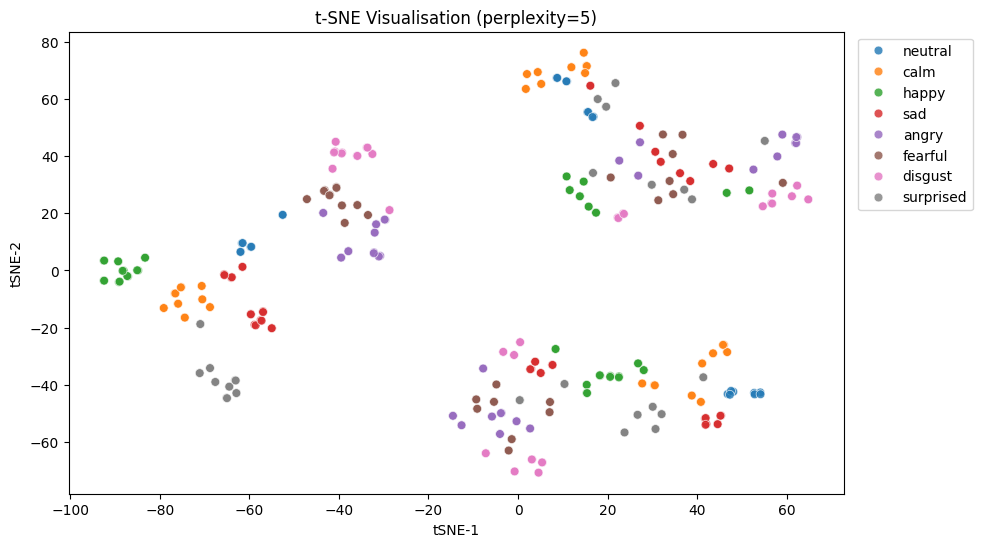

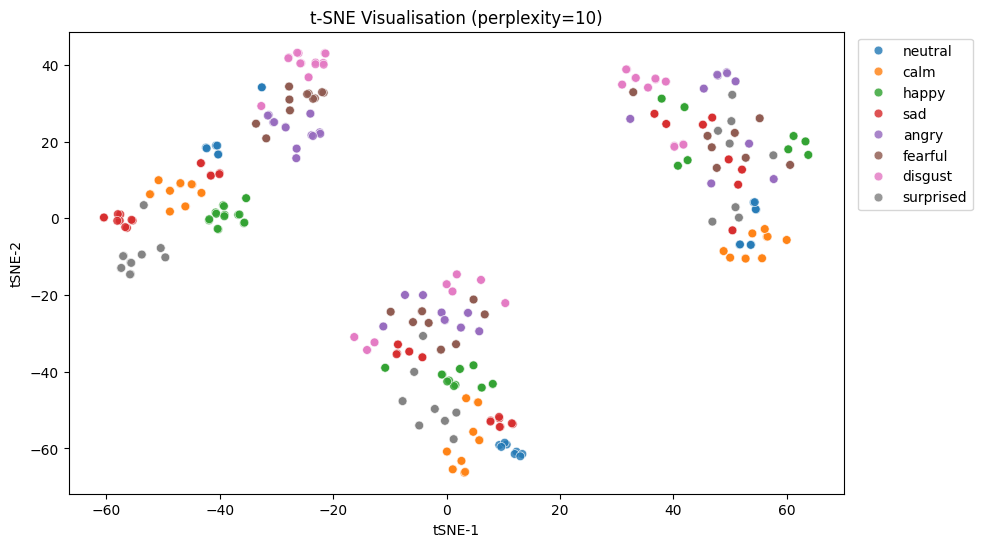

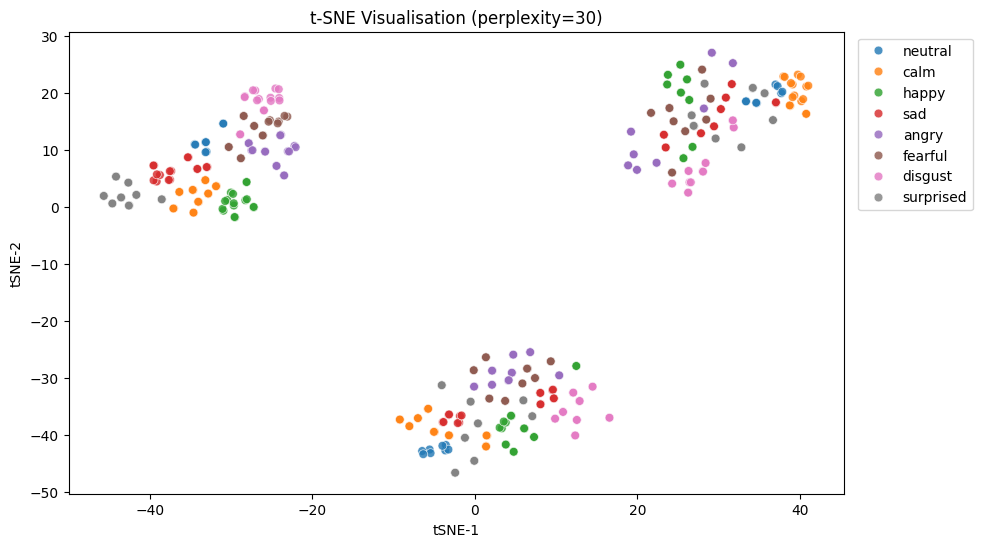

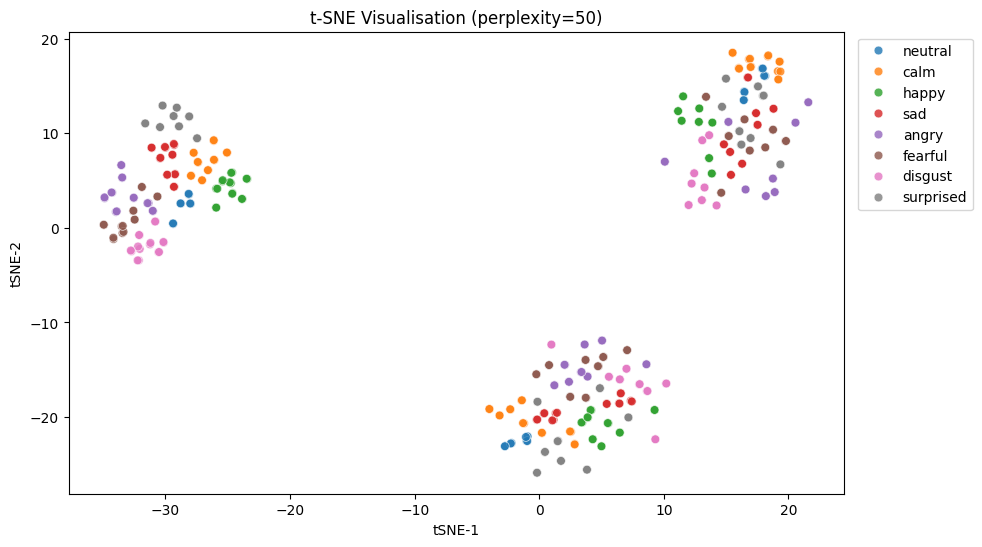

In [21]:
# Visual-only tSNE
for p in [5, 10, 30, 50]:
    visualize_data_distribution(X_visual, good_labels, perplexity=p)

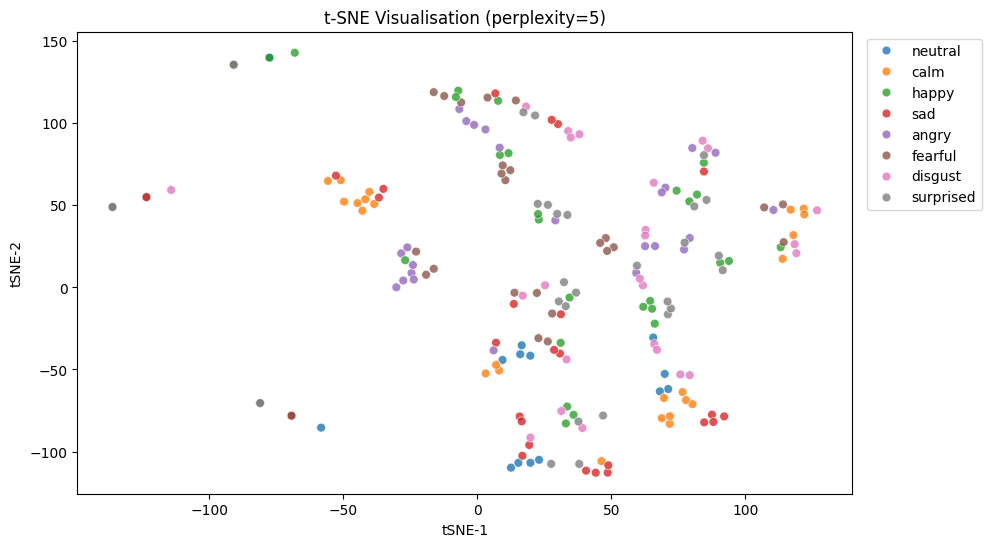

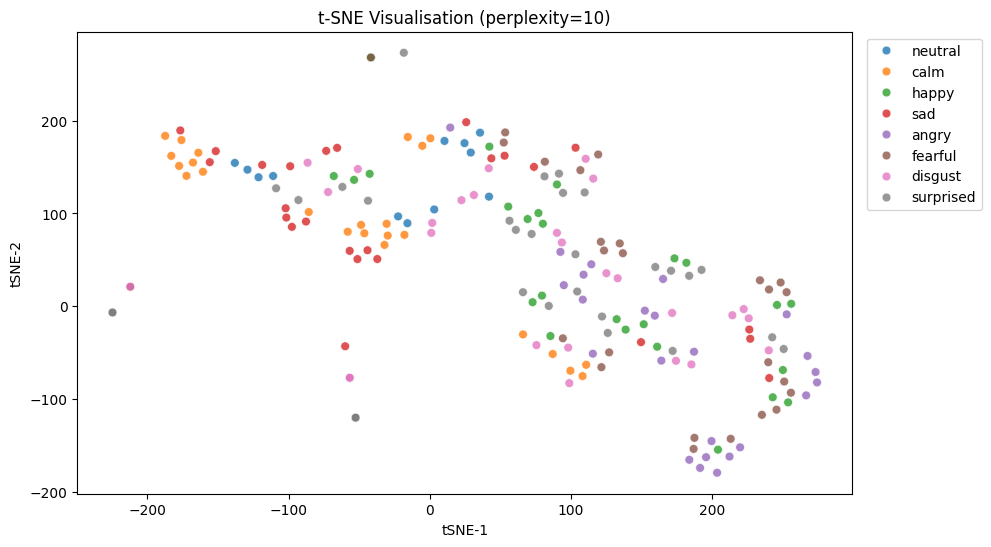

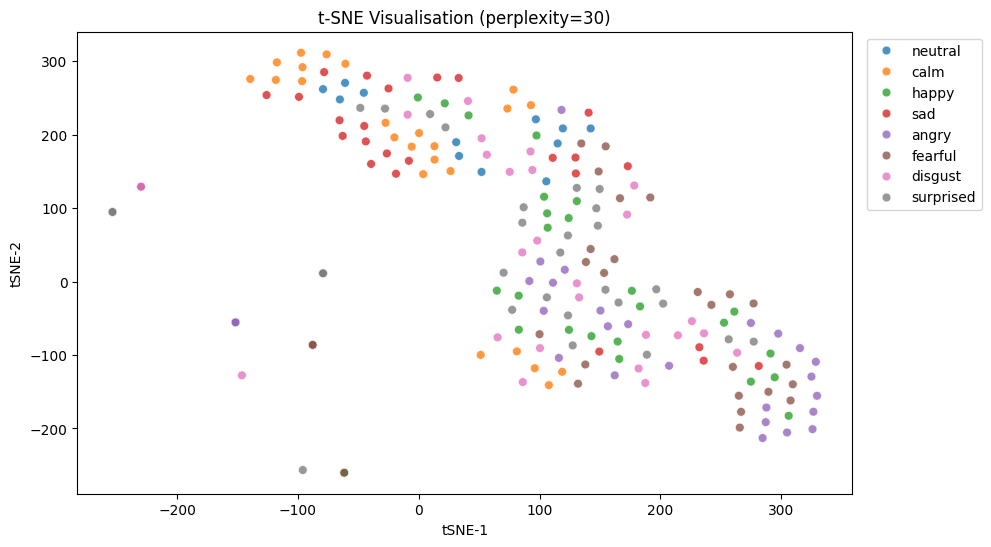

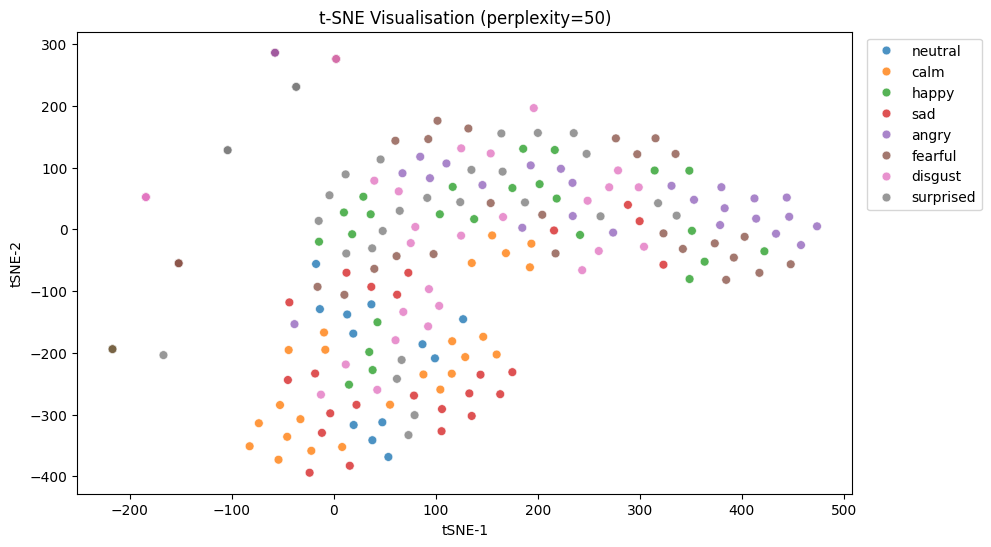

In [22]:
# Audio-only tSNE
for p in [5, 10, 30, 50]:
    visualize_data_distribution(X_audio, good_labels, perplexity=p)

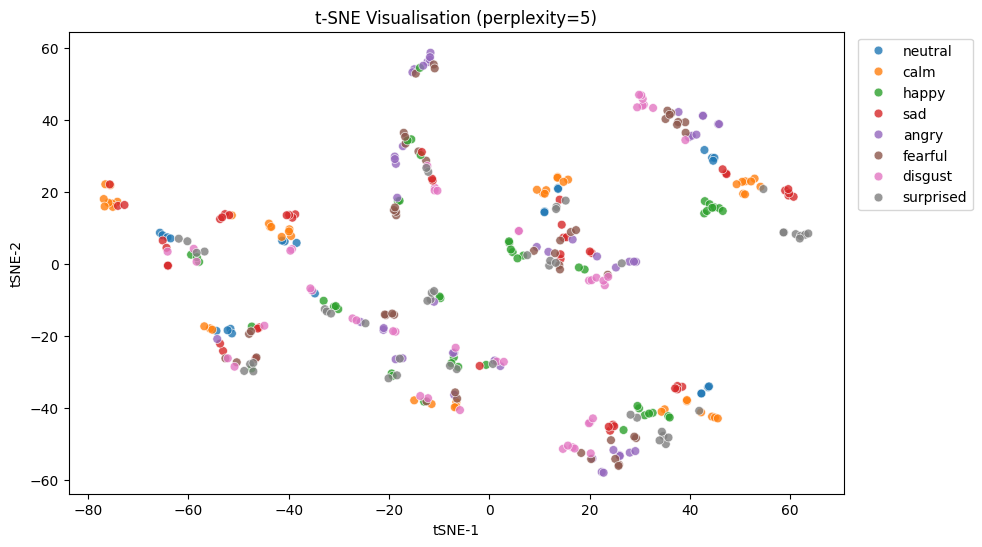

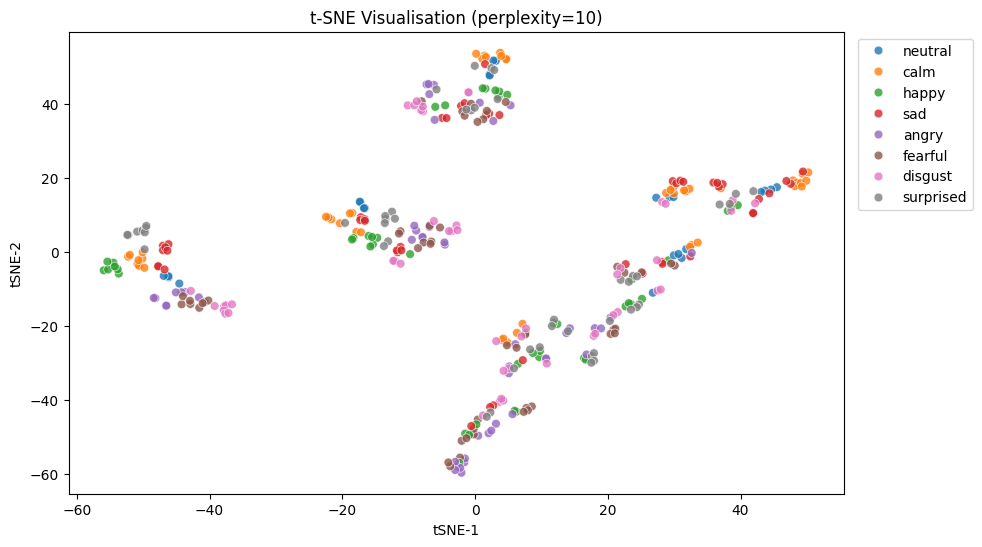

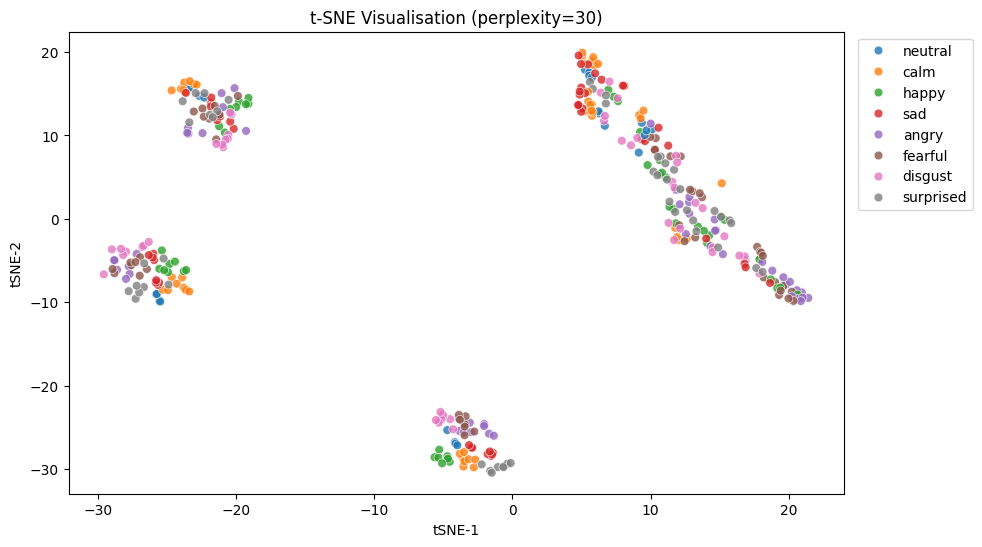

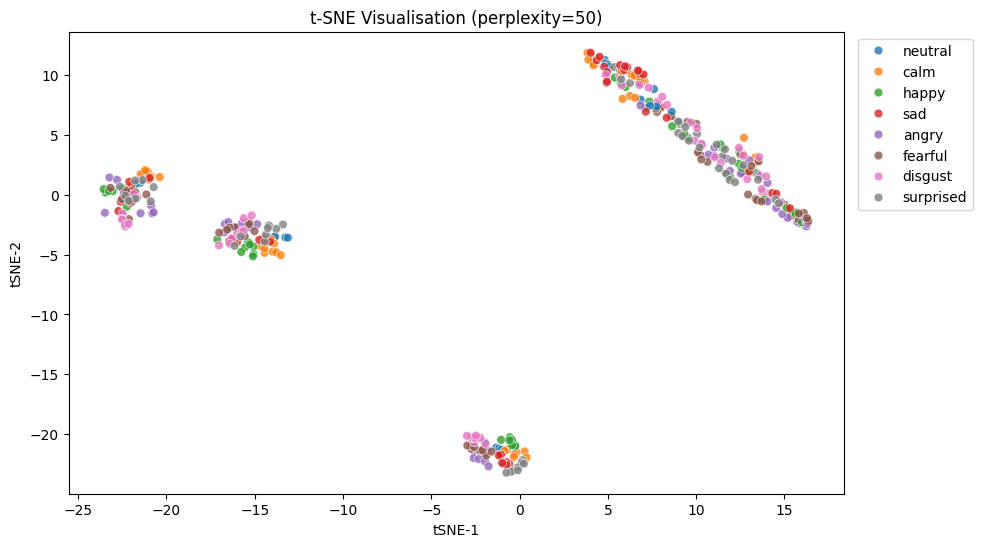

In [23]:
# Multimodal tSNE
for p in [5, 10, 30, 50]:
    visualize_data_distribution(X_multimodal, good_labels, perplexity=p)

# Samples

In [24]:
from cv2.gapi import video
def visualize_samples(video_paths, labels, num_samples=9):
  """
  Visualizes random video samples by displaying their middle frames.

  Args:
      video_paths (list): List of video file paths.
      labels (list): Corresponding emotional labels.
      num_samples (int): Number of samples to display.
  """

  if num_samples > len(video_paths):
    print(f"Error: Number of samples ({num_samples}) exceeds the dataset size ({len(video_paths)}).")
    return

  # Randomly select indices
  indices = random.sample(range(len(video_paths)), num_samples)

  plt.figure(figsize=(12, 8))

  for i, idx in enumerate(indices):
    vp = video_paths[idx]
    frame = get_middle_frame_rgb(vp)

    plt.subplot(3, 3, i+1)
    plt.imshow(frame)
    plt.title(f"Label: {labels[idx]}")
    plt.axis('off')

  plt.tight_layout()
  plt.show()


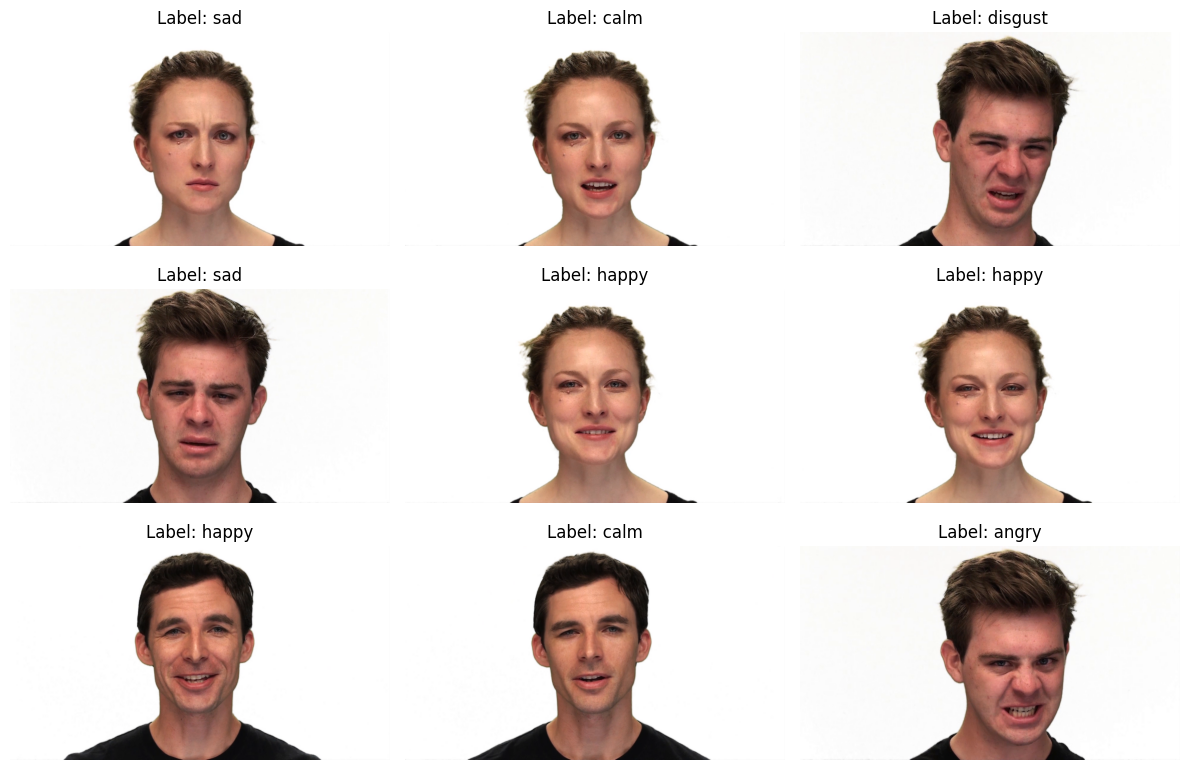

In [25]:
visualize_samples(good_paths, good_labels, num_samples=9)

# Input Distribution

In [26]:
import librosa
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def visualize_input_distribution(video_paths, labels):
    """
    Visualizes raw input distributions for RAVDESS:
      (1) class counts
      (2) video length (#frames)
      (3) middle-frame brightness
      (4) audio duration (seconds)
      (5) audio RMS energy (loudness proxy)
    """
    # (1) Class distribution
    df = pd.DataFrame({"label": labels})
    label_order = ["neutral","calm","happy","sad","angry","fearful","disgust","surprised"]
    label_order = [l for l in label_order if l in set(labels)]

    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x="label", order=label_order)
    plt.xticks(rotation=45)
    plt.title("Input Distribution: Emotion Class Counts")
    plt.xlabel("Emotion")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # (2) Frames per video
    frame_counts = []
    for vp in video_paths:
        cap = cv2.VideoCapture(vp)
        n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        cap.release()
        frame_counts.append(n)

    plt.figure(figsize=(8, 4))
    sns.histplot(frame_counts, bins=25, kde=True)
    plt.title("Input Distribution: Video Length (# Frames)")
    plt.xlabel("# Frames")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # (3) Brightness of middle frame
    brightness = []
    for vp in video_paths:
        frame = get_middle_frame_rgb(vp)
        if frame is None:
            continue
        gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
        brightness.append(float(gray.mean()))

    plt.figure(figsize=(8, 4))
    sns.histplot(brightness, bins=25, kde=True)
    plt.title("Input Distribution: Middle-Frame Brightness")
    plt.xlabel("Mean Pixel Intensity")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # (4) Audio duration + (5) Audio RMS energy
    durations = []
    rms_energy = []

    for vp in video_paths:
        try:
            y, sr = librosa.load(vp, sr=None)

            # duration in seconds
            durations.append(len(y) / sr)

            # RMS energy (average loudness proxy)
            rms = librosa.feature.rms(y=y)[0]   # shape (T,)
            rms_energy.append(float(rms.mean()))

        except Exception as e:
            # skip files that fail audio read
            continue

    plt.figure(figsize=(8, 4))
    sns.histplot(durations, bins=25, kde=True)
    plt.title("Input Distribution: Audio Duration (seconds)")
    plt.xlabel("Seconds")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    sns.histplot(rms_energy, bins=25, kde=True)
    plt.title("Input Distribution: Audio RMS Energy (loudness proxy)")
    plt.xlabel("Mean RMS")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    return {
        "frame_counts": frame_counts,
        "brightness": brightness,
        "audio_durations": durations,
        "audio_rms_energy": rms_energy
    }

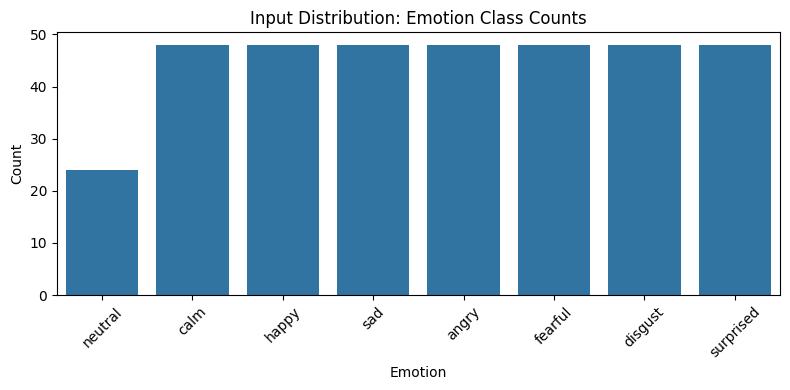

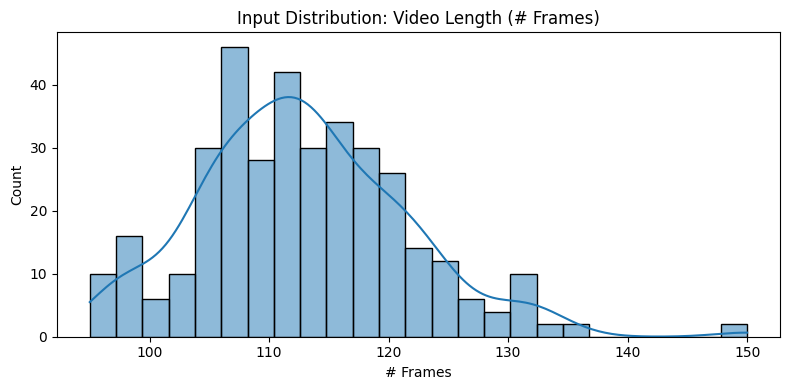

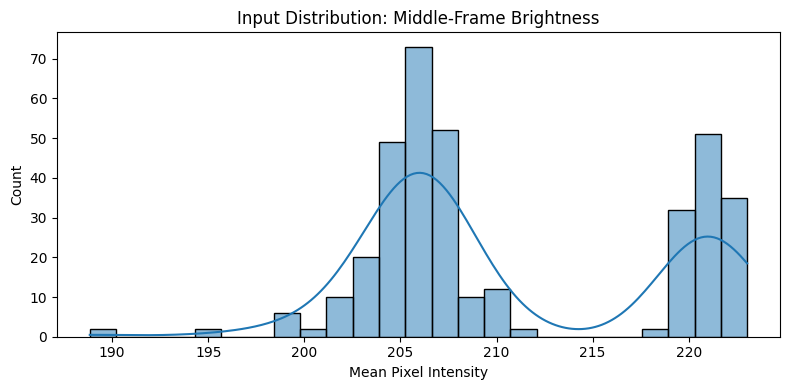

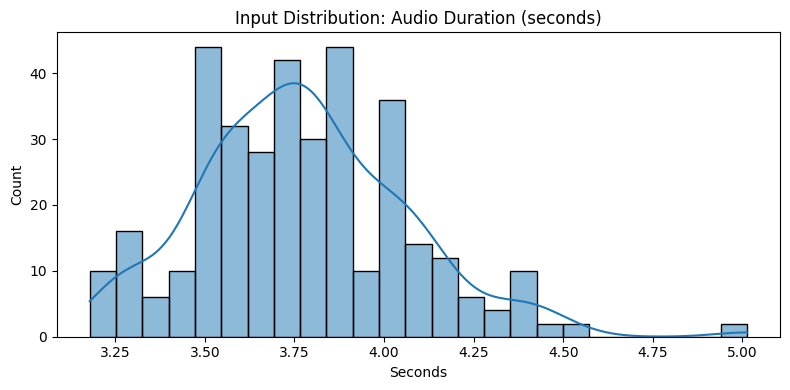

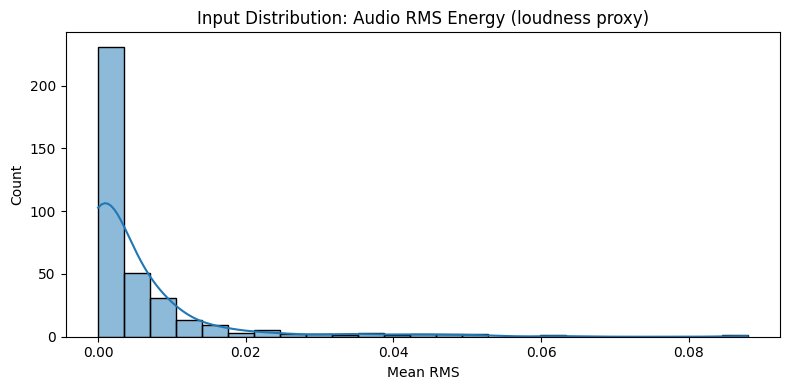

In [27]:
stats = visualize_input_distribution(good_paths, good_labels)

 ### Discuss what visualizations you tried, why, and submit what the visualizations looked like.
Using various perplexity values, we apply _t-SNE_ to the extracted embeddings to assess whether emotions naturally group together in feature space. At moderate perplexity, we observe partial clustering by emotion, with closely related categories (e.g., calm and neutral) overlapping. This indicates that the embeddings capture some emotion-related structure, though the separation is not complete.

Second, we visualised random middle frames from selected clips to verify preprocessing. As shown above, the displayed frames _do_ align with their assigned emotion labels, confirming that we correctly extracted and labelled our frames.

Third, we examined input-level statistics, incldung class counts, video length, brightness, audio duration, and RMS energy. The emotion classes are approximately balanced, reducing concern about any systemic class bias. Video lengths and audio duration are tightly distributed, supporting fixed-length feature extraction. However, brightness and RMS energy show noticeable spread, providing sources of variability prior to model training.

(20 pts) **Question 3**

Now let's consider what evaluation metrics you would want to use in training and validation. Answer the following:

1. What evalution metrics are you planning on using? Why?
2. Are there any other metrics that could be used here or that you considered?
3. List out the pros and cons of the evaluation metrics you decided to go with.

In addition, code up functions that calculate the metric. We have provided a template to start with. This will be used later for when we do start training models, so take some time in designing this!

In [28]:
# Accuracy as an example
def evaluation_metric(predictions, ground_truths):
  num_correct = 0
  num_tot = 0

  for prediction, truth in zip(predictions, ground_truths):
    if prediction == truth:
      num_correct += 1
    num_tot += 1

  if num_tot == 0:
    raise ValueError("Issue reading ground truths/No ground truths provided!")

  return num_correct / num_tot

In [ ]:
# Confusion matrix
# Shortcut: from sklearn.metrics import confusion_matrix
def confusion_matrix_metric(predictions, ground_truths):
  labels = sorted(list(set(ground_truths)))
  label_to_index = {label: i for i, label in enumerate(labels)}

  # Initalise matrix
  size = len(labels)
  matrix = [[0 for _ in range(size) for _ in range(size)]]

  for prediction, truth in zip(predictions, ground_truths):
    pred_idx = label_to_index[prediction]
    truth_idx = label_to_index[truth]
    matrix[pred_idx][truth_idx] += 1 # rows = true labels; cols = predicted labels

  return matrix

In [29]:
# Macro F1 metric
# Shortcut: from sklearn.metrics import f1_score
# Use average='macro' when calling f1_score

def macro_f1_metric(predictions, ground_truths):
    matrix, labels = confusion_matrix_metric(predictions, ground_truths)
    num_classes = len(labels)

    f1_scores = []

    for i in range(num_classes):
        tp = matrix[i][i]

        # False positives = column sum minus tp
        fp = sum(matrix[r][i] for r in range(num_classes)) - tp

        # False negatives = row sum minus tp
        fn = sum(matrix[i][c] for c in range(num_classes)) - tp

        if tp == 0 and (fp == 0 or fn == 0):
            f1_scores.append(0)
            continue

        precision = tp / (tp + fp) if (tp + fp) != 0 else 0
        recall = tp / (tp + fn) if (tp + fn) != 0 else 0

        if precision + recall == 0:
            f1 = 0
        else:
            f1 = 2 * precision * recall / (precision + recall)

        f1_scores.append(f1)

    return sum(f1_scores) / num_classes

## What metrics are you using? Are there other metrics? List out pros and cons.
We intend to use _accuracy_, which gives an overall correctness rate, but does not reveal whether the model performs poorly on specific emotions. To provide a more class-sensitive evaluation, we will also use _macro F1_, which separately computes precision and recall for each emotion, and then averages the resulting F1 equally across all classes. Finally, we will use a _confusion matrix_, which explicitly shows which emotions are misclassifed and where systemic confusion occurs. In summary, the pros and cons of our chosen metrics are:
- Accuracy: simple and interpretable; may obscure class-specific weakness
- Macro F1: sensitive to per-class performance; less immediately interpretable than accuracy
- Confusion matrix: diagnostically informative; not a single scalar summary

Other metrics to consider are _weighted F1_,  which adjusts for class frequency, _balanced accuracy_, which averages per-class recall, and _cross-entropy_, which is useful during probabilistic training but is less interpretable as a standalone evaluation metric.

(15 pts) **Question 4**

For the next part of this assignment, we are going to play around with instruction tuning. Instruction tuning is creating a prompt that you would feed to a model in order to have it complete a certain assignment by constraing what it can output without the need to train. This is when you prompt the model in specifc ways to guarentee a specific output (e.g. one-word labels, value ranges or classifications). Provide prompts that would be able to guarentee the right output based on the data. **Just provide the prompts, you don't need to train the model.**

Scenario 1: You have a dataset of reviews from restaurants, when you see this review:
"This place stinks, the service was awful and the food was not cooked. I will never come back here!"
Provide a prompt that would have the model return the sentiment of the review, which is negative.

Scenario 2: You are looking through a dataset of angry, sad, and happy faces. Provide a prompt that would get the emotion a person is expressing.

Scenario 3: A dataset of novels, with the following paragraph:
"The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."

Provide prompts to get the name of the subject, where they are going, and what they were planning to do.

### Provide prompts
Scenario 1: Classify the sentiment of the following restaurant review. You must respond with exactly one word: **positive** or **negative**. Do NOT add additional explanations or text.

Scenario 2: Classify the emotion expressed in the image. You must respond with exactly one word from the following list: **angry, sad, happy**. Do NOT add additional explanations or text.

Scenario 3: Extract the name, destination and activity of the subject from the paragraph below. Return your answer using exactly the following format:

Name=\<name\> \
Destination=\<location\> \
Activity=\<activity\>

Do NOT include any additional commentary.

**As a bonus part of this assignment (10 points of extra credit)**, we welcome you to do the following: Create a project where you create a dataset (separate from the one you will be using for the rest of the HWs) and train some models on the dataset. For the bonus credit, explain what goal you went with, the model you decided to use, and the evalutaion metrics used. Explain your reasoning for each of the choices. Be as creative as possible!

Here is what we are looking for:
* What is the task you are looking to do
* What dataset you are using
* The modalities you will extract
* What model you will be using
* The evaluation metrics you employ
* Results from training adn testing using the evaluation metrics

Be sure to provide a rationale for each design choice!



In [40]:
# BONUS CODE HERE
## IMPORT MODULES
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix
import urllib.request
import zipfile

## IMPORT DATA
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
if not os.path.exists('UCI HAR Dataset'):
  urllib.request.urlretrieve(url, 'dataset.zip')
  with zipfile.ZipFile('dataset.zip', 'r') as zip_ref:
    zip_ref.extractall()

def load_data(train=True):
    if train:
        X = np.loadtxt('UCI HAR Dataset/train/X_train.txt')  # sensor readings
        y = np.loadtxt('UCI HAR Dataset/train/y_train.txt') - 1 # activity labels
    else:
        X = np.loadtxt('UCI HAR Dataset/test/X_test.txt')
        y = np.loadtxt('UCI HAR Dataset/test/y_test.txt') - 1
    return X, y

## DEFINE TRAIN AND TEST SPLITS
X_tr, y_tr = load_data(train=True)
X_te, y_te = load_data(train=False)

num_classes = len(np.unique(y_tr))

activities = ['Walking', 'Walking Upstairs', 'Walking Downstairs', 'Sitting', 'Standing', 'Laying']

print(f"Training: {X_tr.shape}, Test: {X_te.shape}", "Classes:", num_classes)
print(f"Training head:\n{X_tr[:5], y_tr[:5]}")

Training: (7352, 561), Test: (2947, 561) Classes: 6
Training head:
(array([[ 0.28858451, -0.02029417, -0.13290514, ..., -0.84124676,
         0.17994061, -0.05862692],
       [ 0.27841883, -0.01641057, -0.12352019, ..., -0.8447876 ,
         0.18028889, -0.05431672],
       [ 0.27965306, -0.01946716, -0.11346169, ..., -0.84893347,
         0.18063731, -0.04911782],
       [ 0.27917394, -0.02620065, -0.12328257, ..., -0.84864938,
         0.18193476, -0.04766318],
       [ 0.27662877, -0.01656965, -0.11536185, ..., -0.84786525,
         0.18515116, -0.04389225]]), array([4., 4., 4., 4., 4.]))


Accelerometer features: (7352, 256)
Gyroscope features: (7352, 256)


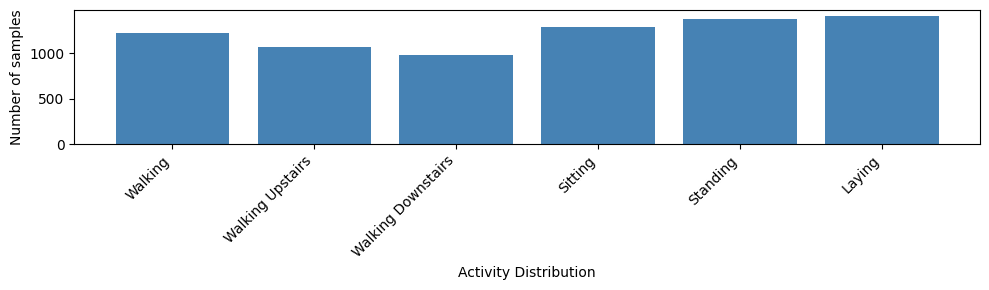

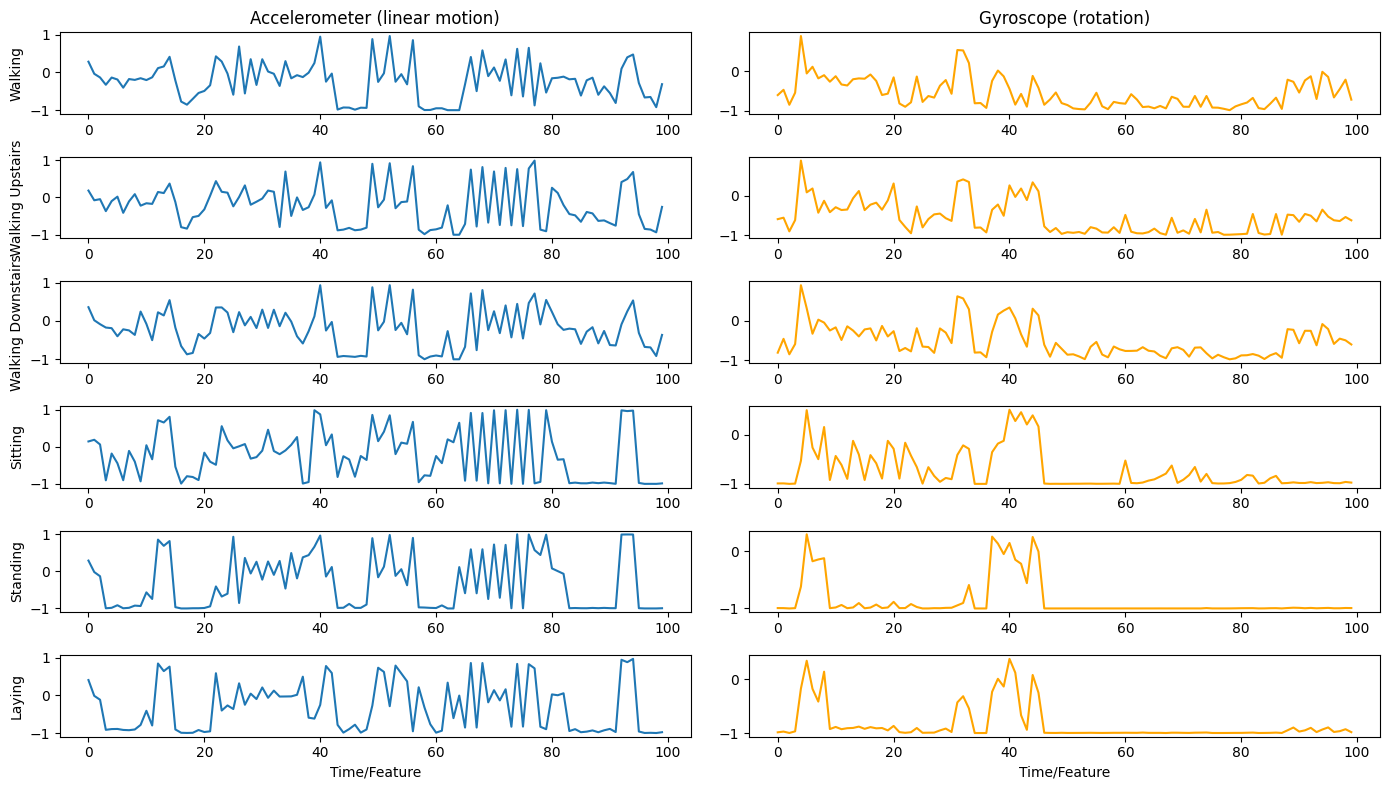

In [44]:
## DEFINE MODALITIES
# First 256 cols are accel data, next 256 cols are gyro data
accel_tr, gyro_tr = X_tr[:, :256], X_tr[:, 256:512]
accel_te, gyro_te = X_te[:, :256], X_te[:, 256:512]

print(f"Accelerometer features: {accel_tr.shape}")
print(f"Gyroscope features: {gyro_tr.shape}")

## VISUALISE MODALITIES
# How many samples per activity?
plt.figure(figsize=(10, 3))
counts = [np.sum(y_tr == i) for i in range(num_classes)]
plt.bar(activities, counts, color='steelblue')
plt.ylabel('Number of samples')
plt.xlabel('Activity Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# How does sensor data look like for each activity?
plt.figure(figsize=(14, 8))

for i in range(6):
    # Get one sample of this activity
    idx = np.where(y_tr == i)[0][0]

    # Plot accelerometer
    plt.subplot(6, 2, i*2 + 1)
    plt.plot(accel_tr[idx, :100])
    plt.ylabel(activities[i], fontsize=10)
    if i == 0:
        plt.title('Accelerometer (linear motion)')
    if i == 5:
        plt.xlabel('Time/Feature')

    # Plot gyroscope
    plt.subplot(6, 2, i*2 + 2)
    plt.plot(gyro_tr[idx, :100], color='orange')
    if i == 0:
        plt.title('Gyroscope (rotation)')
    if i == 5:
        plt.xlabel('Time/Feature')

plt.tight_layout()
plt.show()

In [49]:
## DEFINE MODELS
## BASELINE
m1 = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(256,)),
    layers.Dense(6, activation='softmax')
])

m1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## MULTIMODAL
# Create two separate inputs
accel_in = layers.Input((256,))
gyro_in = layers.Input((256,))

# Process each input separately, then merge
x = layers.Dense(64, activation='relu')(accel_in)
y = layers.Dense(64, activation='relu')(gyro_in)
combined= layers.concatenate([x, y])

# Make a final prediction
out = layers.Dense(6, activation='softmax')(combined)

m2 = keras.Model(inputs=[accel_in, gyro_in], outputs=out)
m2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [52]:
## TRAIN MODELS
m1.fit(accel_tr, y_tr, epochs=30, batch_size=64, validation_split=0.2, verbose=0)
m2.fit([accel_tr, gyro_tr], y_tr, epochs=30, batch_size=64, validation_split=0.2, verbose=0)


Accelerometer-only: 0.932
Multimodal:         0.936
Improvement:        +0.4%


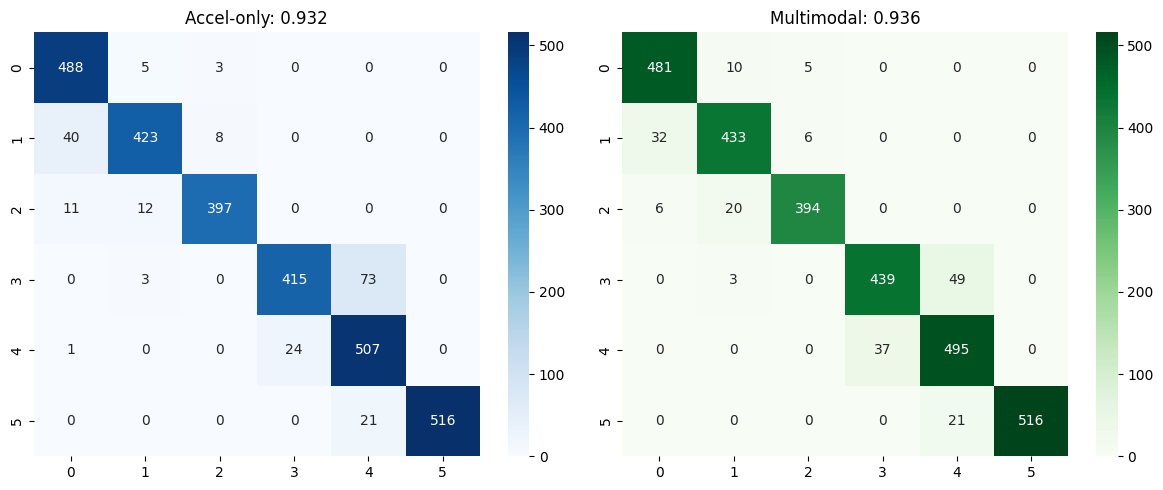

In [54]:
## EVALUATION & RESULTS
# Accuracy
acc1 = m1.evaluate(accel_te, y_te, verbose=0)[1]
acc2 = m2.evaluate([accel_te, gyro_te], y_te, verbose=0)[1]

print(f"\nAccelerometer-only: {acc1:.3f}")
print(f"Multimodal:         {acc2:.3f}")
print(f"Improvement:        +{(acc2-acc1)*100:.1f}%")

# Confusion matrix
pred1 = m1.predict(accel_te, verbose=0).argmax(axis=1)
pred2 = m2.predict([accel_te, gyro_te], verbose=0).argmax(axis=1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_te, pred1), annot=True, fmt='d', ax=ax[0], cmap='Blues')
ax[0].set_title(f'Accel-only: {acc1:.3f}')
sns.heatmap(confusion_matrix(y_te, pred2), annot=True, fmt='d', ax=ax[1], cmap='Greens')
ax[1].set_title(f'Multimodal: {acc2:.3f}')
plt.tight_layout()
plt.show()

### Bonus
### Bonus
Our *task* is to classify ordinary human activities, including walking, walking upstairs or downstairs, sitting, standing or laying, using smartphone sensor data from the UCI HAR Dataset (10,299 samples, 30 subjects). The smartphones are equipped with two physically distinct sensors, defining our two modalities:
1. accelerometer data (256 features), capturing linear motion, and
2. gyroscope data (256 features), capturing rotational motion.

From this, we construct a baseline model, specifically, a dense neural network (64 hidden units) using only accelerometer data. We also construct a multimodal model, which separates processing for each sensor (64 units each), before concatenating and joining through a prediction layer.

We evaluate using _accuracy_ (appropriate for balanced 6-class data) and _confusion matrices_ (to identify difficult activity pairs). Results show accelerometer-only achieves 93.2% accuracy, while multimodal fusion achieves 93.6% (+0.4% improvement). The confusion matrices reveal multimodal better distinguishes sitting/standing by incorporating gyroscope orientation data, ultimately demonstrating that combining complementary sensor modalities helps to improve classification.

(5 pts) **Question 5**

Now, let's take some time to reflect. We have dug deep into the data collection and process portion of machine learning. Take some time to discuss:

1. The most interesting topic discussed in this homework assignment.
2. A challenging aspect that you did not expect to deal with and what insights you used to address it.
3. How you feel about the overall quality of your dataset? Is there anything lacking? What is particularly great about it?

There is no specific right answer we are looking for, answer how you think!

### Reflection
1. It was most interesting to see that, even without training a classifier, the visual features already showed some separation between emotions. In the _t-SNE_ plots, emotions like 'happy' and 'angry' formed separate clusters, whilst similar emotions like 'calm' and 'neutral' overlapped. This suggests that facial structure alone provides meaningful signal for emotion classification.

2. A main challenge was to decide how to reduce each video and audio clip to a fixed-sized input, given that videos contain many frames and audio changes over time. To this end, we chose to use the middle frame for visual modality, and average MFCC features for audio. This represented a trade-off between simplicity and risk of losing temporal detail.

3. The dataset is clean, labelled, and mostly balanced across emotions. The clips are also similar in length, making preprocessing straightfoward! A possible limitation might be that emotions are acted and recorded in controlled settings, so expressions may be exaggerated, artificial or less representative of real-world behaviour.